## 🚀 Exercise 8: More on sampling Distributions & the Central Limit Theorem (CLT) 
We will use **real-world data** from the **California Housing** dataset (1990 U.S. Census block groups).

## Data context (real-world meaning)
Each row is a California census block group (1990). A few variables we’ll use:

- `MedInc`: median income (in tens of thousands of dollars)
- `HouseAge`: median house age
- `AveRooms`: average number of rooms
- `AveOccup`: average household occupancy
- `MedHouseVal`: median house value (in hundreds of thousands of dollars)

**In the tasks, we'll treat the full dataset as a large "population" and study what happens when we take smaller samples—like a survey or a study would.**


**What you'll learn**
- What a *sampling distribution* is
- How sample size changes variability (standard error)
- Why the CLT is useful (and when it can be slow)
- How normal approximations connect to confidence intervals and decision-making


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing

In [2]:
# Set random seed for reproducibility
RSEED = 42

In [3]:
# Load real-world dataset
cal = fetch_california_housing(as_frame=True)
df = cal.frame.copy()
df.head(), df.shape

(   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 
    Longitude  MedHouseVal  
 0    -122.23        4.526  
 1    -122.22        3.585  
 2    -122.24        3.521  
 3    -122.25        3.413  
 4    -122.25        3.422  ,
 (20640, 9))

#### ✅ Task for students: 
Keep only the variables we need in the dataframe and reset the index ["MedInc", "HouseAge", "AveRooms", "AveOccup", "MedHouseVal"]

In [4]:
cols = ["MedInc", "HouseAge", "AveRooms", "AveOccup", "MedHouseVal"]
df = df[cols].dropna().reset_index(drop=True)

In [5]:
# Print = quick summaries
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### ✅ Task for students: Visualizing a "population" distribution

We will assume the data represents xqa population and we will say how would sampling play out.

Before sampling, vizualize the distribution of a real variable of population: **median house value** (`MedHouseVal`).

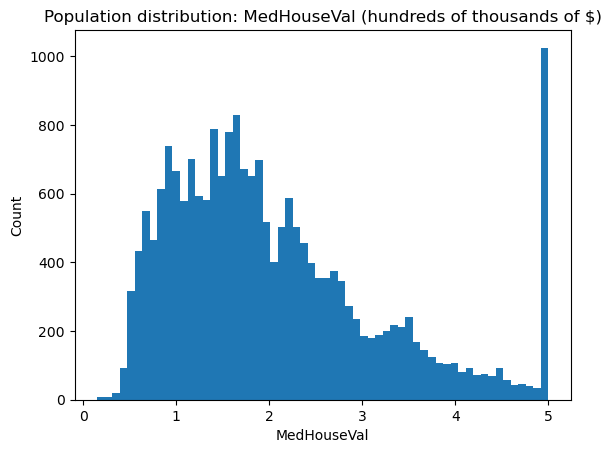

In [6]:
x = df["MedHouseVal"].to_numpy()

plt.figure()
plt.hist(x, bins=60)
plt.title("Population distribution: MedHouseVal (hundreds of thousands of $)")
plt.xlabel("MedHouseVal")
plt.ylabel("Count")
plt.show()

#### ✅ Task for students: 
Desrcibe the shape of the distribution, is it normal? compute the Skewness as a quick diagnostic.

In [7]:
stats.skew(x)
# the data is not a normaly distributed and rather a right skewed

np.float64(0.9776922140978419)

#### ✅ Task for students: Sampling distribution of the mean (real-world: estimating average house value)

**Scenario:** A city analyst wants to estimate the *average* median house value across California block groups.  
They can only sample **n**  groups (budget constraint).

**Student task**
1. For each sample size `n in {5, 30, 100}`, draw many random samples each with sample with 1000 repititions from `MedHouseVal` (with replacement). Use np.random.choice for this purpose.
3. Compute the **sample mean** for each draw of the sample means.
4. Plot the sampling distribution of the mean for each `n`.
5. Compare how the spread changes as `n` increases.

Use np.std(ddof=1) or pd.Series(m).std() to compute standard deviation and answer:

- How does variability of the sample mean change with `n`?  
- Does the shape become more “normal” with larger `n`?


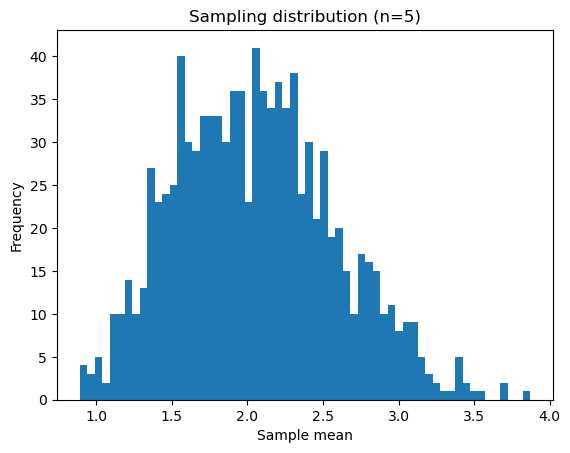

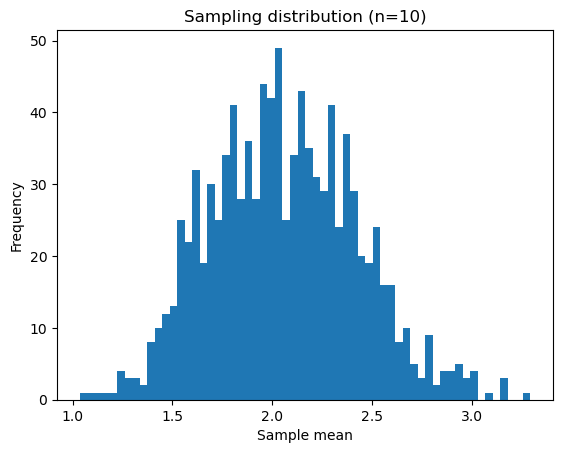

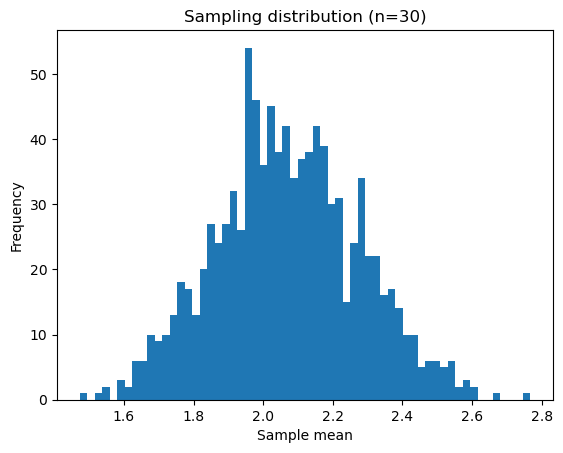

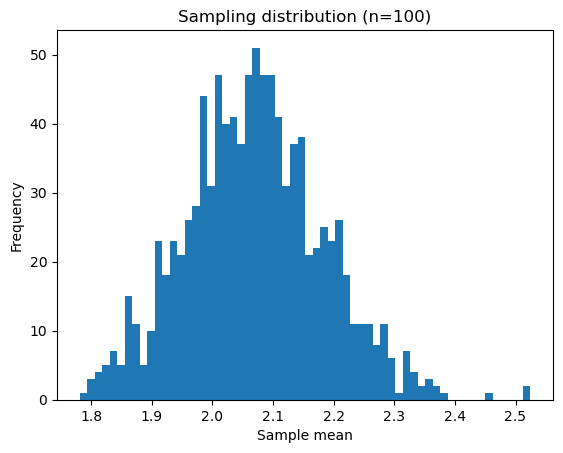

5      2.056014
10     2.058697
30     2.070283
100    2.069744
Name: Empirical Mean, dtype: float64
5      0.526708
10     0.367825
30     0.206509
100    0.113153
Name: Empirical SD, dtype: float64


In [9]:
# the following function should return array of sample means of shape (reptitions,)
def sample_means(data, n, reps=1000, seed=RSEED):
    # Your code here
    np.random.seed(RSEED)
    sample_means = np.random.choice(data, size=(reps, n), replace=True).mean(axis=1)
    return sample_means

data = df["MedHouseVal"].to_numpy()
ns = [5, 10, 30, 100]

mean_values = {n: sample_means(data, n) for n in ns}

for n, m in mean_values.items():
    plt.hist(m, bins=60)
    plt.title(f"Sampling distribution (n={n})")
    plt.xlabel("Sample mean")
    plt.ylabel("Frequency")
    plt.show()

# Find and print the mean value of sample means for each n and empirical standard deviation
print(pd.Series({n: m.mean() for n, m in mean_values.items()}, name="Empirical Mean"))
print(pd.Series({n: m.std() for n, m in mean_values.items()}, name="Empirical SD"))

✅ Question 1: How does variability of the sample mean change with n?
Answer (simple):
- Variability decreases as n increases
- Sample means become more concentrated

Why:
- Larger samples average out randomness
- Extreme values cancel out

👉 This follows the √n rule

✅ Question 2: Does the shape become more normal with larger n?
Answer: ✅ Yes
- n = 5 → irregular, skewed
- n = 30 → smoother
- n = 100 → bell-shaped

Why:
- Central Limit Theorem
- Averages tend toward a normal distribution

#### ✅ Task for students: complete this  conclusion:
- The larger n the closer the sample mean distribution get to the symmetric shape of normal distribution with mean value ~ mean value of the original population

#### NOTE:

#### How to answer sampling / CLT questions (short steps)

1. **Check what is averaged**
   If it’s *sample mean* → think **CLT**.

2. **Check sample size (n)**
   Larger **n** → more data per average.

3. **State the two effects**

   * Shape → becomes **more normal**
   * Spread → becomes **less variable (narrower)**

4. **Give the reason**
   Averaging cancels randomness (**Central Limit Theorem**).

---

#### One-line template (use in exams)

> As sample size increases, the sampling distribution of the mean becomes more normal and less variable due to the Central Limit Theorem.

---

#### 5-second memory trick

Always say these TWO effects

(These are the only two things examiners want)

**Effect 1: *Shape***

- Small n → irregular / skewed
- Large n → normal (bell-shaped)

**Effect 2: *Spread***

- Small n → wide / variable
- Large n → narrow / less variable

#### ✅ Task for students: Standard error: connect simulation to the formula (real-world: “typical estimation error”)

**Scenario:** You report an average house value from a sample, but decision-makers ask: “How much could this estimate vary if we repeated the survey?”

**Student task**
1. Compute the **population standard deviation** of `MedHouseVal` from the full dataset (treat as population).
2. For `n = 30, 100, 400`, compare:
   - simulated SD of the sample mean (from Task 1 style simulation) with 1000 repititions
   - theoretical approximation:  $ \text{SE}(\bar X) \approx \sigma / \sqrt{n}$
3. Summarize the results in a small table.

**What to look for**
- Does simulated SD match $\sigma/\sqrt{n}$
- Why does this matter for planning sample sizes?

In [11]:
sigma = np.std(data) # treat full dataset as population
print("The population standard deviation:", sigma)

ns2 = [5, 30, 100, 400]
reps = 1000

rows = []
for n in ns2:
    m = sample_means(data, n, reps=reps, seed=RSEED)
    sim_se = np.std(m)
    theo_se = sigma / np.sqrt(n)
    rows.append({"n": n, "simulated_SE": sim_se, "theoretical_sigma/sqrt(n)": theo_se})

pd.DataFrame(rows)

The population standard deviation: 1.1539282040412253


,n,simulated_SE,theoretical_sigma/sqrt(n)
0,5,0.526708,0.516052
1,30,0.206509,0.210678
2,100,0.113153,0.115393
3,400,0.057285,0.057696


#### ✅ Task for students: add a Conclusion
> Repeated sampling shows that the variability of the sample mean decreases as sample size increases. The simulated standard error closely matches the theoretical value $( \sigma / \sqrt{n} )$, confirming that larger samples produce more stable and reliable estimates. This relationship is essential for planning surveys, as it allows analysts to choose sample sizes that balance accuracy and cost.

**NOTE: Why $( \sigma / \sqrt{n} )$**

#### You want to know the **average height** of people in a city.

---

#### Case 1: Ask **1 person**

* That one person might be **very tall** or **very short**
* Your “average” is **very unreliable**

👉 Huge error

---

#### Case 2: Ask **4 people**

* Some tall, some short
* Errors start to cancel a bit

👉 Error is smaller, but still there

---

#### Case 3: Ask **100 people**

* Tall and short people cancel out a lot
* Average becomes **very stable**

👉 Small error

---

#### Key idea (this is the heart ❤️)

> **Averaging cancels randomness, but it cancels it slowly.**

It does **NOT** cancel linearly.

---

#### Now the ONE rule you must remember

#### If you want to reduce error:

* To make error **2× smaller** → need **4× more data**
* To make error **3× smaller** → need **9× more data**
* To make error **10× smaller** → need **100× more data**

👉 That pattern is **square root**

That is why it’s **√n**.

#### ✅ Task for students: Sampling distribution of a proportion (real-world: “How common are expensive areas?”)

**Scenario:** A housing policy team asks:  
> “What fraction of block groups have median house value above $300k?”

In the dataset, `MedHouseVal` is in *hundreds of thousands*, so $300k corresponds to `MedHouseVal > 3.0`.

**Student task**
1. Compute the “population” proportion \(p\) using all rows.
2. For `n = 10`, `n = 30`,  and `n = 400`, simulate the sampling distribution of $(\hat p)$ (sample proportion).
3. Compare the shape to a normal approximation:
  $ \hat p \approx \mathcal{N}(p,\; p(1-p)/n) $
4. Interpret results: when does the normal approximation look reasonable?


The mean MedHouseVal from the Population: 0.18585271317829458


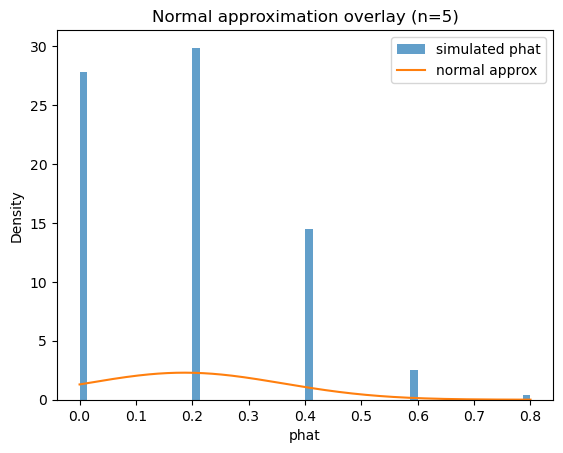

n=5: mean=0.1812, SD=0.1716, approx=0.1740


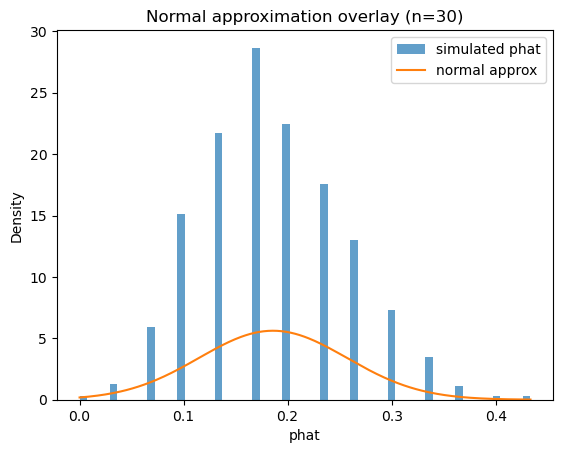

n=30: mean=0.1854, SD=0.0696, approx=0.0710


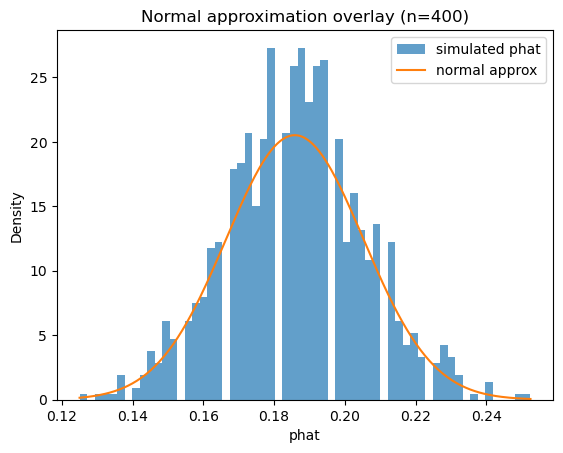

n=400: mean=0.1860, SD=0.0195, approx=0.0194


In [12]:
y = (df["MedHouseVal"].to_numpy() > 3.0).astype(int)
p = y.mean() # we can imagine this as if it is for hte whole population
print("The mean MedHouseVal from the Population:", p)


for n in [5, 30, 400]:
    phat = sample_means(y, n, reps=1000)


    # overlay normal curve on histogram
    mu = p
    sd = np.sqrt(p * (1 - p) / n)
    xs = np.linspace(phat.min(), phat.max(), 300)

    plt.hist(phat, bins=60, density=True, alpha=0.7, label="simulated phat")
    plt.plot(xs, stats.norm.pdf(xs, mu, sd), label="normal approx")
    plt.title(f"Normal approximation overlay (n={n})")
    plt.xlabel("phat")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    print(f"n={n}: mean={phat.mean():.4f}, SD={phat.std(ddof=1):.4f}, approx={sd:.4f}")

#### Formula:

$[
\hat p \approx \mathcal{N}\left(p,; \frac{p(1-p)}{n}\right)
]$

#### What this REALLY means

| Symbol     | Meaning (simple)                         |
| ---------- | ---------------------------------------- |
| (p)        | True fraction of expensive areas         |
| (\hat p)   | Estimated fraction from a sample         |
| (n)        | Sample size                              |
| (p(1-p))   | Natural variability of yes/no data       |
| (p(1-p)/n) | Variability of the **sample proportion** |

👉 Bigger **n** → smaller variability
👉 So estimates become more stable

---

#### Intuition (very important)

* Estimating a proportion is like averaging **0s and 1s**
* Averaging many values reduces randomness
* Same CLT idea as sample means

#### Question 1: *How does variability change with n?*

#### Answer (always correct):

> Variability of the sample proportion decreases as n increases.

---

#### Question 2: *Does the shape become more normal?*

#### Answer:

> Yes. For small n the distribution is discrete and irregular, but for large n it becomes smooth and approximately normal due to the Central Limit Theorem.

---

#### Question 3: *When is the normal approximation reasonable?*

#### Answer:

> When both $(np \ge 10) and (n(1-p) \ge 10)$, meaning we expect enough successes and failures.

---

#### Question 4: *Why does this matter?*

#### Answer:

> It allows us to use normal-based confidence intervals and uncertainty estimates for proportions.

---

#### One short paragraph you can always write (memorize this)

> The sampling distribution of the sample proportion becomes less variable and more normally distributed as the sample size increases. For small samples, the distribution is discrete and irregular, making the normal approximation poor. For larger samples, the normal approximation works well when both (np) and (n(1-p)) are sufficiently large, consistent with the Central Limit Theorem.

---

#### 🧠 10-second memory trick

* **Proportion = average of 0/1**
* **More data → smoother**
* **Big n → normal**

---